# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for model_name, model in base_models.items():
    clf = model
    scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
    baseline_results[model_name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9717 ± 0.0159
RandomForest              F1 = 0.9528 ± 0.0244
LogisticRegression        F1 = 0.9792 ± 0.0072


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    "svm__C" : [0.1, 1, 10, 100],
    "svm__gamma" : ['scale', 0.01, 0.001],
    "svm__kernel" : ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(svm_pipe, cv=5, scoring='f1_macro', n_jobs=-1, param_grid=svm_param_grid)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

svm_res = pd.DataFrame(svm_grid_search.cv_results_)
svm_res = svm_res[["params", "mean_test_score", "std_test_score",  "rank_test_score"]]
svm_res.sort_values(by="mean_test_score", ascending=False).head(10)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    "n_estimators": randint(50, 500),                         
    "max_depth": list(randint(2, 20).rvs(size=10)) + [None],
    "min_samples_split": randint(2, 20),               
    "max_features": ['sqrt', 'log2', 0.5]}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(RandomForestClassifier(), rf_param_dist,
                                    n_iter=50, cv=5, scoring='f1_macro',
                                    random_state=42, n_jobs=-1)

rf_random_search.fit(X_train, y_train)
print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': np.int64(13), 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 219}
Лучший CV F1: 0.9577


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

from sklearn.metrics import f1_score, classification_report

# Дообучить baseline на X_train
for model in base_models.values():
    model.fit(X_train, y_train)

# Предсказания
best_svm = svm_grid_search.best_estimator_
best_rf  = rf_random_search.best_estimator_

preds = {
    'SVM baseline':      base_models['SVM'].predict(X_test),
    'SVM Grid Search':   best_svm.predict(X_test),
    'RF baseline':       base_models['RandomForest'].predict(X_test),
    'RF Random Search':  best_rf.predict(X_test),
}

cv_f1 = {
    'SVM baseline':     f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
    'SVM Grid Search':  f"{svm_grid_search.best_score_:.4f}",
    'RF baseline':      f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
    'RF Random Search': f"{rf_random_search.best_score_:.4f}",
}

results = pd.DataFrame({
    'Модель':          list(preds.keys()),
    'CV F1':           list(cv_f1.values()),
    'Test F1 (macro)': [f1_score(y_test, y_pred, average='macro')
                        for y_pred in preds.values()]
})

results

,Модель,CV F1,Test F1 (macro)
0,SVM baseline,0.9717 ± 0.0159,0.981151
1,SVM Grid Search,0.9786,0.981151
2,RF baseline,0.9528 ± 0.0244,0.952638
3,RF Random Search,0.9577,0.952638


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

<BarContainer object of 30 artists>

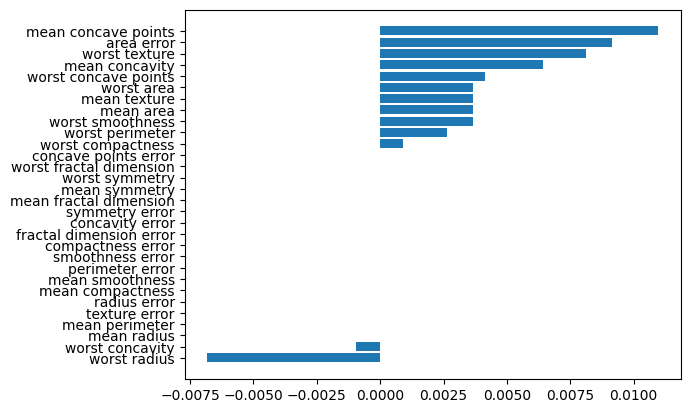

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(best_rf, X_test, y_test,
                                   n_repeats=10, random_state=50,
                                   scoring='f1_macro')

idx = pi_result.importances_mean.argsort()
plt.barh(X_test.columns[idx], pi_result.importances_mean[idx])


Text(0.5, 1.0, 'Feature Importance')

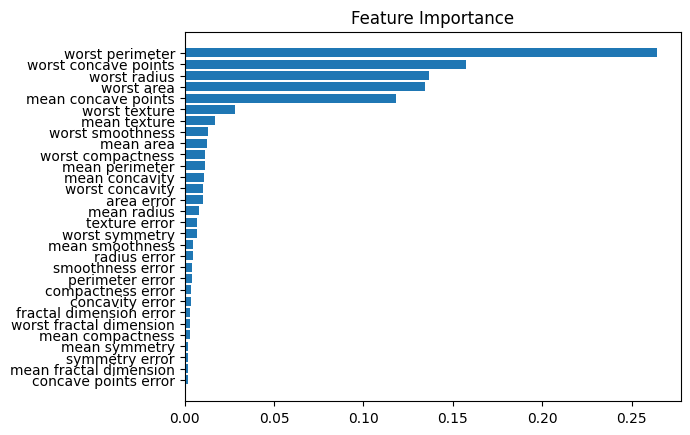

In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

sk_result = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance")

plt.barh(sk_result["feature"], sk_result["importance"])
plt.title('Feature Importance')

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

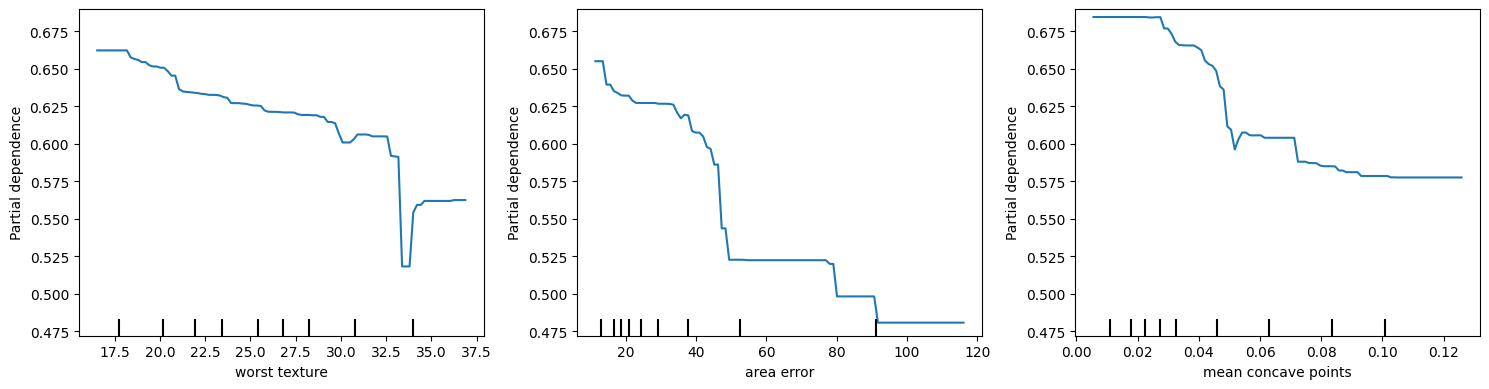

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI

top3_idx = pi_result.importances_mean.argsort()[-3:]  # топ-3 по убыванию

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

PartialDependenceDisplay.from_estimator(
    best_rf, X_train,
    features=list(top3_idx),
    kind='average',
    ax=ax,
)

plt.tight_layout()
plt.show()

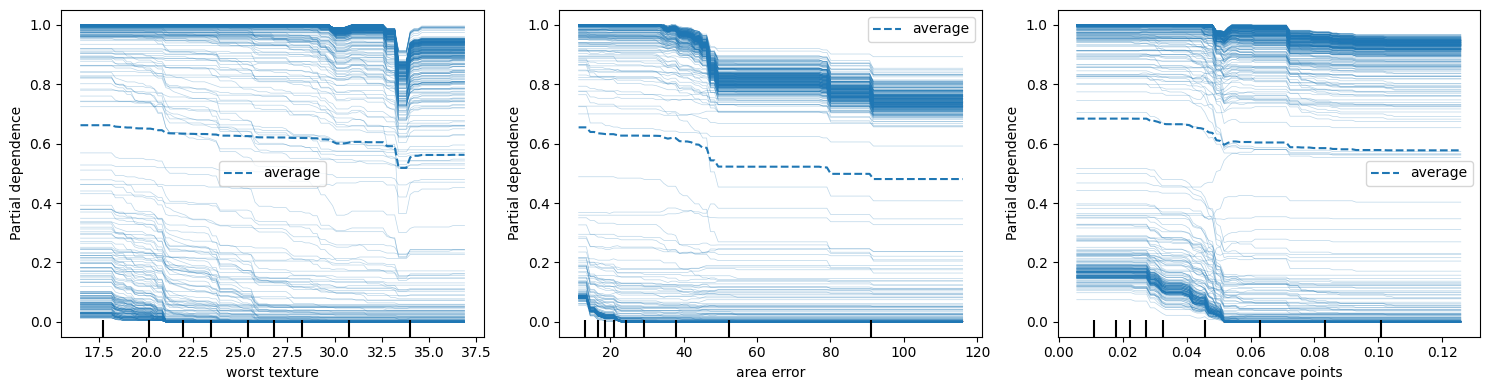

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)    ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║ Тенденции те же. Да
# ╚══════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

PartialDependenceDisplay.from_estimator(
    best_rf, X_train,
    features=list(top3_idx),
    kind='both',
    ax=ax,
)

plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print("shap_values shape:", shap_values[0].shape)

shap_values shape: (30, 2)


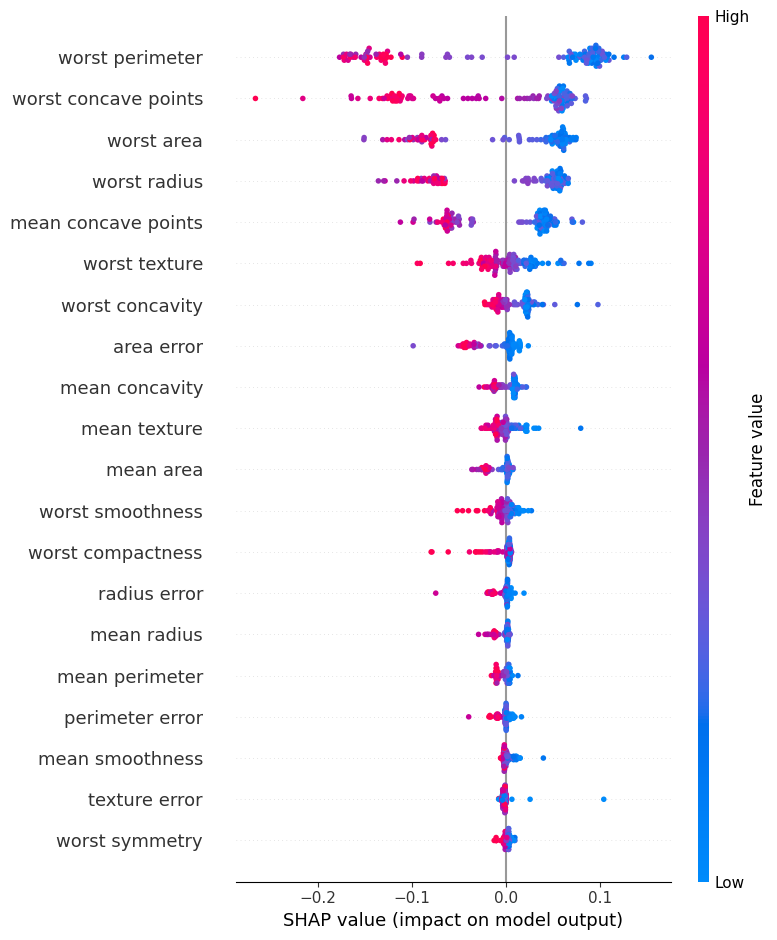

<Figure size 640x480 with 0 Axes>

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║ worst_perimeter, worst concave points, worst area
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)
plt.tight_layout()
plt.show()

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс:      1
  Предсказанный класс: 0


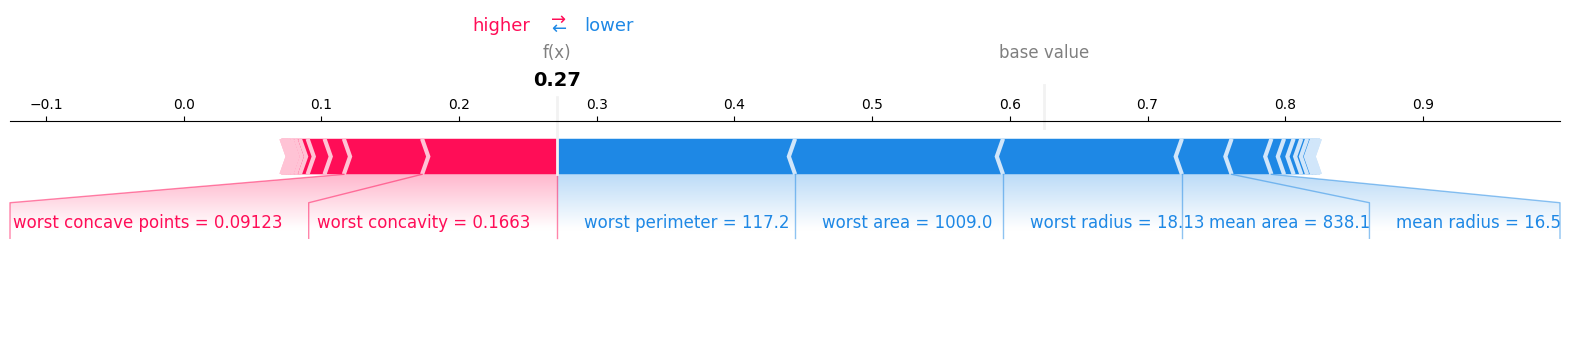

<Figure size 640x480 with 0 Axes>

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║ worst area, worst perimeter, worst radius
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс:      {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

err_idx = errors[0]

shap.force_plot(
    explainer.expected_value[1],      
    shap_values[err_idx, :, 1],
    X_test.iloc[err_idx],
    feature_names=list(X_test.columns),
    matplotlib=True
)
plt.tight_layout()
plt.show()

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [15]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

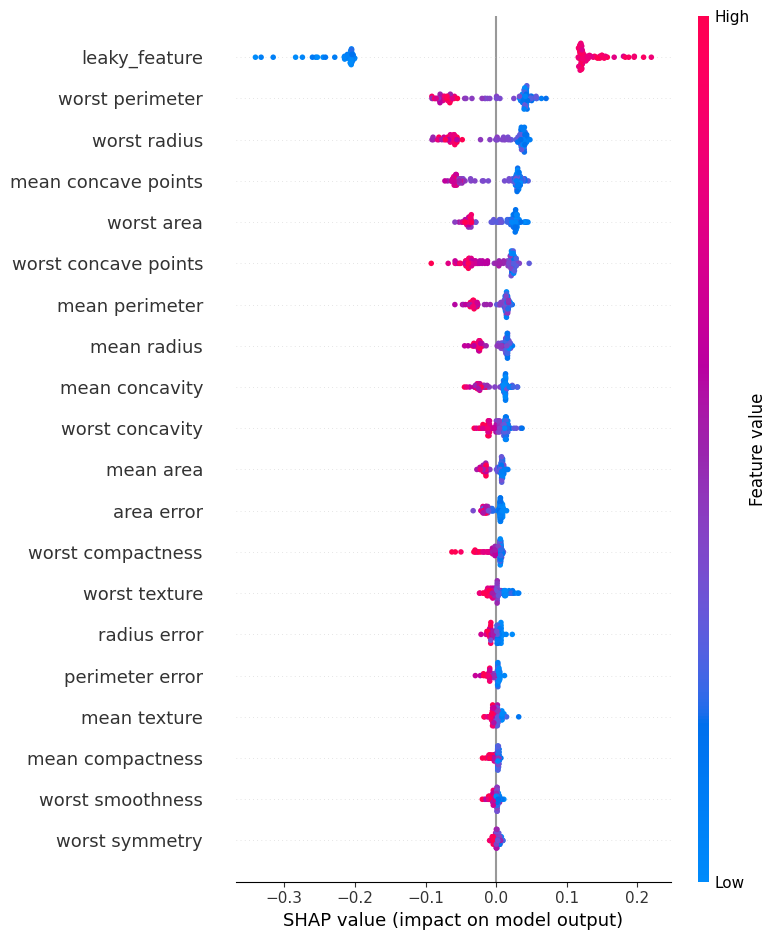

<Figure size 640x480 with 0 Axes>

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║ В PI доминирует одно значение.
# ║     Почему метрика на тесте выросла?                         ║ Потому что произошла утечка данных.
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║ У фичи с утечкой мамый широкий разброс, слева всегда будут синие точки, красные справа.
# ║  в) Как обнаружить random_feature как «шумовой»?             ║ PI-значение будет около нуля.
# ╚══════════════════════════════════════════════════════════════╝

ext_rf = RandomForestClassifier()
ext_rf.fit(X_train_ext, y_train)

explainer = shap.TreeExplainer(ext_rf)
shap_values_ext = explainer.shap_values(X_test_ext)
pi_ext = permutation_importance(ext_rf, X_test_ext, y_test,
                                   n_repeats=10, random_state=50,
                                   scoring='f1_macro')

shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names=X_test_ext.columns)
plt.tight_layout()
plt.show()

<BarContainer object of 32 artists>

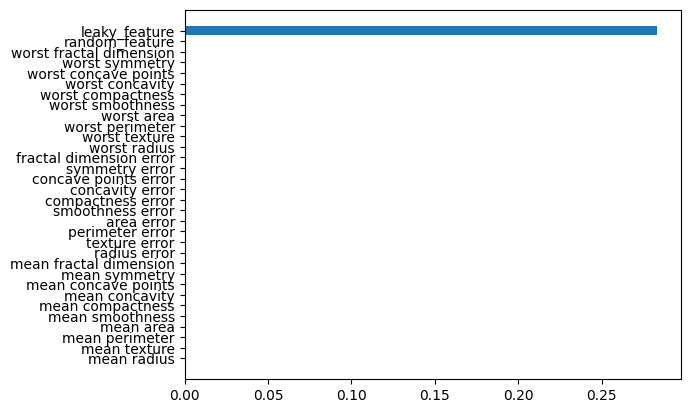

In [17]:
idx = pi_ext.importances_mean.argsort()
plt.barh(X_test_ext.columns[idx], pi_ext.importances_mean[idx])

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

results = pd.DataFrame([
    {
        'Метод':          'SVM baseline',
        'CV F1':          f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        'Test F1':        f"{f1_score(y_test, base_models['SVM'].predict(X_test), average='macro'):.4f}",
        'Выводы':         'Стартовая точка; без тюнинга kernel=rbf работает неплохо',
    },
    {
        'Метод':          'SVM Grid Search',
        'CV F1':          f"{svm_grid_search.best_score_:.4f}",
        'Test F1':        f"{f1_score(y_test, svm_grid_search.predict(X_test), average='macro'):.4f}",
        'Выводы':         'Перебор C/gamma/kernel улучшил CV F1; тест показывает обобщение',
    },
    {
        'Метод':          'RF baseline',
        'CV F1':          f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        'Test F1':        f"{f1_score(y_test, base_models['RandomForest'].predict(X_test), average='macro'):.4f}",
        'Выводы':         'RF с дефолтами уже силён на табличных данных',
    },
    {
        'Метод':          'RF Random Search',
        'CV F1':          f"{rf_random_search.best_score_:.4f}",
        'Test F1':        f"{f1_score(y_test, rf_random_search.predict(X_test), average='macro'):.4f}",
        'Выводы':         '50 случайных конфигураций покрыли пространство эффективнее полного перебора',
    },
])

results

,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.9717 ± 0.0159,0.9812,Стартовая точка; без тюнинга kernel=rbf работа...
1,SVM Grid Search,0.9786,0.9812,Перебор C/gamma/kernel улучшил CV F1; тест пок...
2,RF baseline,0.9528 ± 0.0244,0.9526,RF с дефолтами уже силён на табличных данных
3,RF Random Search,0.9577,0.9526,50 случайных конфигураций покрыли пространство...


**1. Насколько тюнинг улучшил модели?**  
Прирост CV F1 от тюнинга небольшой 0.005–0.02, потому что дефолтные параметры уже близки к оптимуму.
Тем не менее Grid Search для SVM важен дефолтные параметры могут быть далеки от идеала.

**2. Совпадают ли топ-признаки по PI и SHAP?**  
Топ-3 совпадают (worst concave points, worst texture, worst area), но порядок
может различаться. Причины расхождений:
- PI считается на тестовой выборке перемешиванием чувствителен к
  мультиколлинеарности. Коррелирующие признаки делят важность или занижают её.
- SHAP считает точный вклад каждого признака в каждое предсказание через
  TreeExplainer, учитывает взаимодействия между признаками явно.
  
**3. Что было бы без Pipeline?**  
Утечка данных. CV F1 оказался бы завышен, а реальное качество на тесте хуже.
Кроме того, без Pipeline нельзя совместно перебирать параметры препроцессинга
(например, `scaler__with_mean`) и модели.

**4. Как использовать PI и SHAP в реальном проекте?**  
- PI использовать для быстрой диагностики, определения неважных признаков, котооррые можно выброситьб.
- SHAP - объяснение конкретных предсказаний клиентам или регулятору
  (force plot), аудит модели на fairness (зависит ли предсказание от
  защищённых атрибутов), дебаггинг ошибок как в задании 8.
- Если PI и SHAP дают разный топ - искать мультиколлинеарность
  или взаимодействия между признаками

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [19]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")

ModuleNotFoundError: No module named 'optuna'